#  Étude de la malnutrition liée au poids chez les Adultes  au Cameroun
les données antropiques( poids, taille et imc) des hommes adultes etant indisponibles dans les donnees de l eds Cameroun 2028, nous allons centrer notre etude sur les femmes adultes

##  Plan du notebook
1. Chargement & présentation des données
2. Préprocessing (NaN, codes spéciaux, IQR, VIF)
3. Statistiques descriptives
4. Visualisations
5. Tests d'hypothèses
6. Analyses multivariées (ACP, PLS, OLS, Logistique, K-Means)
7. Régressions pénalisées et quantile
8. Régression Logistique Ordinale
9. Machine Learning (10 modèles)
10. Optimisation, comparaison et choix du modèle final
11. Importance des variables
12. Conclusion


## 1. Chargement et présentation des données

Le fichier `CMIR71FL.csv` est le fichier individuel récodé des femmes de l'enquête **DHS Cameroun 2018**. Il contient **5 102 variables** pour **14 677 femmes**. Nous sélectionnons 42 variables pertinentes pour l'étude de la malnutrition pondérale.

In [ ]:
#importation des bibliotheques
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score  
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA 
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import time
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
import warnings; warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

TARGET_VARS = ['CASEID','V012','V013','V025','V024','V106','V107','V133','V130','V131','V190','V191',
'V501','V502','V437','V438','V445','V463A','V463B','V463Z','V463AA','V201','V202','V203','V212',
'V213','V225','V714','V715','V716','V717','V745A','V745B','V157','V158','V159','V136','V137',
'V161','V113','V116','V155']

df = pd.read_csv('CMIR71FL.csv', usecols=TARGET_VARS, low_memory=False)
print(f"Forme : {df.shape}")
df.head()

Forme : (14677, 42)


,CASEID,V012,V013,V024,V025,V106,V107,V113,V116,V130,...,V463Z,V463AA,V501,V502,V714,V715,V716,V717,V745A,V745B
0,1 125 2,31,4,5,1,2,3.0,12,23,1,...,1.0,0.0,1,1,1,0.0,71,9,0,0
1,1 125 3,19,1,5,1,0,NaN,12,23,1,...,1.0,0.0,5,2,0,NaN,0,0,0,0
2,1 147 2,22,2,5,1,2,4.0,14,22,4,...,1.0,0.0,1,1,1,9.0,78,8,0,0
3,1 147 3,16,1,5,1,1,6.0,14,22,4,...,1.0,0.0,0,0,0,NaN,0,0,0,0
4,1 191 2,17,1,5,1,0,NaN,21,22,4,...,1.0,0.0,1,1,0,0.0,0,0,0,0


### Dictionnaire des variables retenues

| Code DHS | Variable lisible | Description |
|----------|------------------|-------------|
| V012 | age | Âge en années |
| V025 | milieu | 1=Urbain, 2=Rural |
| V024 | region | Région du Cameroun |
| V106 | education | 0=Aucune, 1=Primaire, 2=Secondaire, 3=Supérieur |
| V190 | richesse | Quintile de richesse (1=très pauvre → 5=très riche) |
| V445 | imc_dhs | IMC calculé × 100 |
| V437/V438 | poids/taille | Mesures anthropométriques |
| V463A/AA | tabac | Tabagisme |
| V201 | enfants_total | Nombre d'enfants nés |
| V155 | alphabetisation | Capacité de lecture |
| V157/158/159 | médias | Journal, radio, TV |


## 2. Préprocessing

- Recodage : codes 99, 999, 9998, 9999 → NaN (codes DHS de non-réponse).
- Calcul IMC : `V445/100` puis recalcul depuis `V437/V438` si manquant.
- Exclusion : IMC hors [12 ; 60] (biologiquement impossibles), femmes enceintes (IMC biaisé).
- Imputation : médiane pour continues, mode pour catégorielles.
- Winsorisation 1%-99% sur variables continues.

In [ ]:
# Renommage 
RENAME = {'V012':'age',
          'V013':'age_groupe',
          'V024':'region',
          'V025':'milieu',
          'V106':'education',
          'V107':'annees_etudes',
          'V133':'annees_education_unique',
          'V130':'religion',
          'V131':'ethnie',
          'V190':'richesse',
          'V191':'richesse_score',
          'V501':'statut_marital',
          'V502':'statut_union',
          'V437':'poids_kg10',
          'V438':'taille_cm10',
          'V445':'imc_dhs',
          'V463A':'fume_cigarette',
          'V463AA':'fume_actuel',
          'V201':'enfants_total',
          'V213':'enceinte',
          'V714':'travaille',
          'V745A':'possede_maison',
          'V157':'lit_journal',
          'V158':'ecoute_radio',
          'V159':'regarde_tv',
          'V136':'taille_menage',
          'V137':'enfants_moins_5ans',
          'V155':'alphabetisation',
          'V717':'occupation_groupe'
        }
df = df.rename(columns=RENAME)

# Codes spéciaux → NaN
for col in df.columns:
    if df[col].dtype in ['float64','int64'] and col not in ['CASEID','richesse_score','imc_dhs','poids_kg10','taille_cm10']:
        df[col] = df[col].replace([99,999,9998,9999], np.nan)

# IMC propre
df['imc'] = df['imc_dhs']/100.0
df.loc[~df['imc'].between(12,60), 'imc'] = np.nan
df['poids_kg'] = df['poids_kg10']/10.0
df['taille_m'] = df['taille_cm10']/1000.0
mask = df['imc'].isna() & df['poids_kg'].between(25,200) & df['taille_m'].between(1.2,2.2)
df.loc[mask,'imc'] = df.loc[mask,'poids_kg'] / df.loc[mask,'taille_m']**2

# Exclusion enceintes + IMC valide
df_a = df[df['imc'].between(12,60) & (df['enceinte']!=1)].copy()
print(f"Échantillon final : {len(df_a)} femmes")

Échantillon final : 6255 femmes


In [95]:
# Classification IMC OMS
def classe(b):
    if b<18.5: return 0
    if b<25: return 1
    if b<30: return 2
    return 3
df_a['imc_classe'] = df_a['imc'].apply(classe)
df_a['imc_classe_label'] = df_a['imc_classe'].map({0:'Maigreur',1:'Normal',2:'Surpoids',3:'Obésité'})
print(df_a['imc_classe_label'].value_counts())
print((df_a['imc_classe_label'].value_counts(normalize=True)*100).round(2))

imc_classe_label
Normal      3586
Surpoids    1481
Obésité      828
Maigreur     360
Name: count, dtype: int64
imc_classe_label
Normal      57.33
Surpoids    23.68
Obésité     13.24
Maigreur     5.76
Name: proportion, dtype: float64


## 3-4. Statistiques descriptives et visualisations

In [ ]:
FEATURES = ['age','milieu','education','annees_education_unique','richesse','richesse_score',
'statut_union','fume_actuel','enfants_total','travaille','taille_menage','lit_journal',
'ecoute_radio','regarde_tv','alphabetisation','religion','possede_maison','occupation_groupe']

# Imputation simple pour continuer
for c in FEATURES:
    if df_a[c].dtype=='float64' and df_a[c].nunique()>6:
        df_a[c] = df_a[c].fillna(df_a[c].median())
    else:
        df_a[c] = df_a[c].fillna(df_a[c].mode().iloc[0])

print("IMC global :")
print(df_a['imc'].describe().round(2))
print("\nIMC urbain vs rural :")
print(df_a.groupby('milieu')['imc'].describe().round(2))

IMC global :


count    6255.00
mean       24.57
std         5.01
min        12.71
25%        21.19
50%        23.58
75%        26.84
max        56.40
Name: imc, dtype: float64

IMC urbain vs rural :
         count   mean   std    min   25%    50%    75%    max
milieu                                                       
1       3405.0  25.57  5.43  14.52  21.8  24.45  28.29  56.40
2       2850.0  23.36  4.16  12.71  20.7  22.74  25.15  54.71


 ## Distribution IMC par catégories

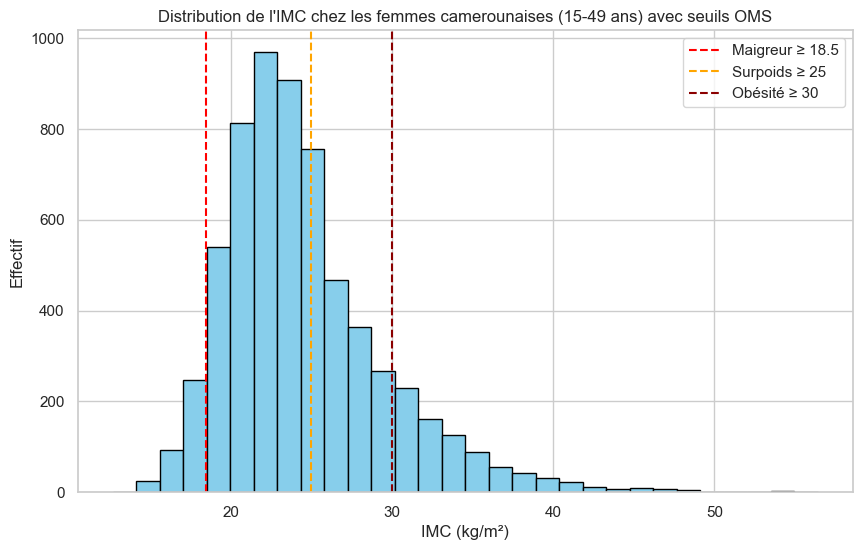

In [97]:
imc = df_a['imc'].dropna()   # on enlève les valeurs manquantes

# Création de l'histogramme
plt.figure(figsize=(10,6))
plt.hist(imc, bins=30, color="skyblue", edgecolor="black")

# Ajoutons les catégories
plt.axvline(x=18.5, color="red", linestyle="--", label="Maigreur ≥ 18.5")
plt.axvline(x=25, color="orange", linestyle="--", label="Surpoids ≥ 25")
plt.axvline(x=30, color="darkred", linestyle="--", label="Obésité ≥ 30")

# Titres et labels
plt.title("Distribution de l'IMC chez les femmes camerounaises (15-49 ans) avec seuils OMS")
plt.xlabel("IMC (kg/m²)")
plt.ylabel("Effectif")
plt.legend()

plt.show()

 ## Boxplots par variables clés

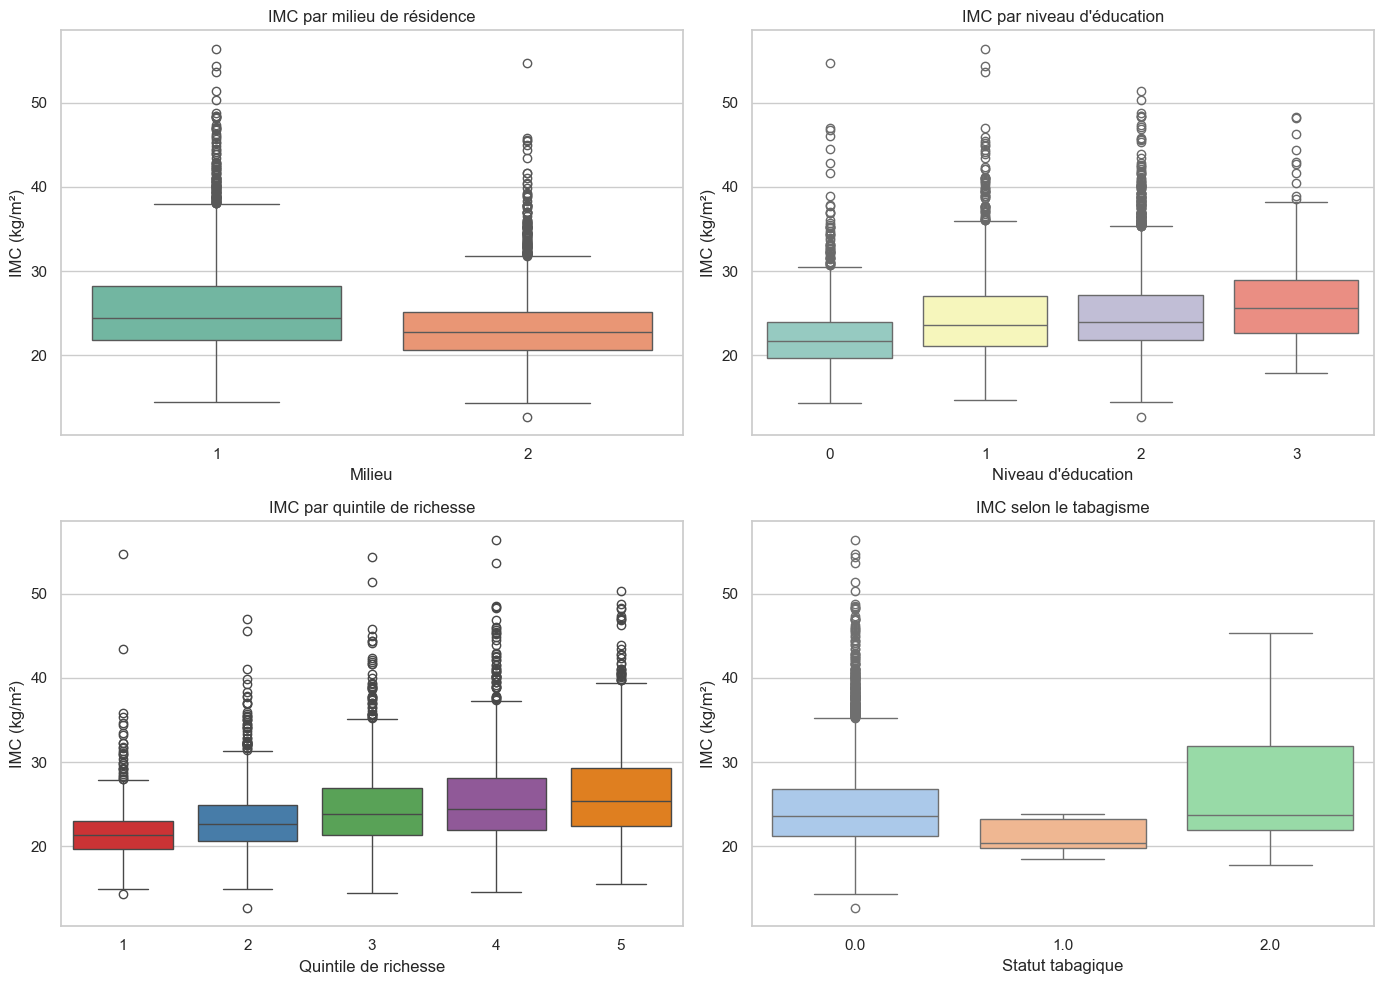

In [98]:
plt.figure(figsize=(14,10))

# 1. IMC par milieu (urbain vs rural)
plt.subplot(2,2,1)
sns.boxplot(x="milieu", y="imc", data=df_a, palette="Set2")
plt.title("IMC par milieu de résidence")
plt.xlabel("Milieu")
plt.ylabel("IMC (kg/m²)")

# 2. IMC par niveau d'éducation
plt.subplot(2,2,2)
sns.boxplot(x="education", y="imc", data=df_a, palette="Set3")
plt.title("IMC par niveau d'éducation")
plt.xlabel("Niveau d'éducation")
plt.ylabel("IMC (kg/m²)")

# 3. IMC par quintile de richesse
plt.subplot(2,2,3)
sns.boxplot(x="richesse", y="imc", data=df_a, palette="Set1")
plt.title("IMC par quintile de richesse")
plt.xlabel("Quintile de richesse")
plt.ylabel("IMC (kg/m²)")

# 4. IMC selon le tabagisme
plt.subplot(2,2,4)
sns.boxplot(x="fume_actuel", y="imc", data=df_a, palette="pastel")
plt.title("IMC selon le tabagisme")
plt.xlabel("Statut tabagique")
plt.ylabel("IMC (kg/m²)")

plt.tight_layout()
plt.show()

les fumeurs ont une imc faibles
plus on est riche plus notre imc augmente

## Relation âge × IMC

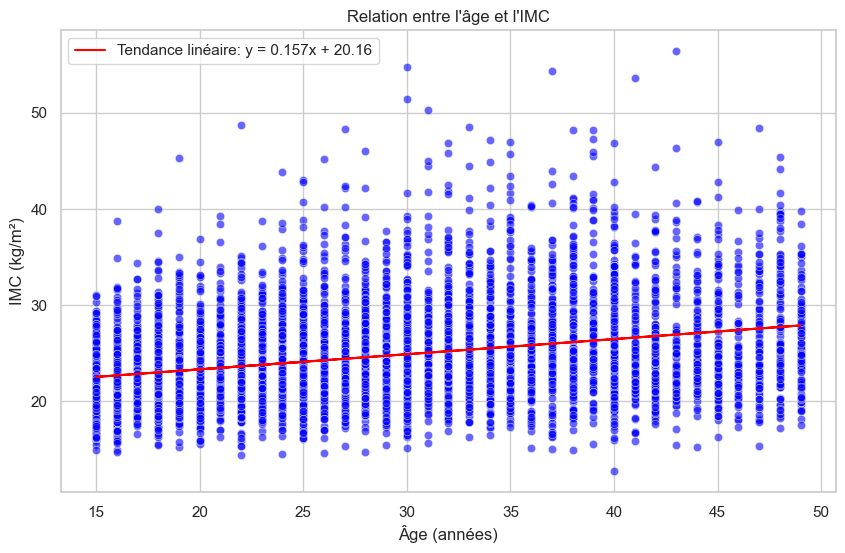

In [99]:
age = df_a['age']
imc = df_a['imc']

plt.figure(figsize=(10,6))

# Nuage de points
sns.scatterplot(x=age, y=imc, color="blue", alpha=0.6)

# Ajustement linéaire (droite de tendance)
coef = np.polyfit(age, imc, 1)   # régression linéaire simple
poly1d_fn = np.poly1d(coef)

plt.plot(age, poly1d_fn(age), color="red", label=f"Tendance linéaire: y = {coef[0]:.3f}x + {coef[1]:.2f}")

# Titres et labels
plt.title("Relation entre l'âge et l'IMC")
plt.xlabel("Âge (années)")
plt.ylabel("IMC (kg/m²)")
plt.legend()

plt.show()

interpretaion:  Tendance linéaire positive nette : `IMC ≈ 0.14 × âge + 19.5`. À 30 ans, l'IMC moyen est ~23.7 ; à 45 ans, ~25.6.

### Matrice de corrélation Spearman


In [100]:
# Vérifier les colonnes disponibles
print(df_a.columns.tolist())

['CASEID', 'age', 'age_groupe', 'region', 'milieu', 'education', 'annees_etudes', 'V113', 'V116', 'religion', 'ethnie', 'annees_education_unique', 'taille_menage', 'enfants_moins_5ans', 'alphabetisation', 'lit_journal', 'ecoute_radio', 'regarde_tv', 'V161', 'richesse', 'richesse_score', 'enfants_total', 'V202', 'V203', 'V212', 'enceinte', 'V225', 'poids_kg10', 'taille_cm10', 'imc_dhs', 'fume_cigarette', 'V463B', 'V463Z', 'fume_actuel', 'statut_marital', 'statut_union', 'travaille', 'V715', 'V716', 'occupation_groupe', 'possede_maison', 'V745B', 'imc', 'poids_kg', 'taille_m', 'imc_classe', 'imc_classe_label']


Colonnes utilisées pour la corrélation : ['age', 'milieu', 'education', 'annees_education_unique', 'richesse', 'richesse_score', 'fume_actuel', 'enfants_total', 'travaille', 'taille_menage', 'lit_journal', 'ecoute_radio', 'regarde_tv', 'alphabetisation', 'imc']


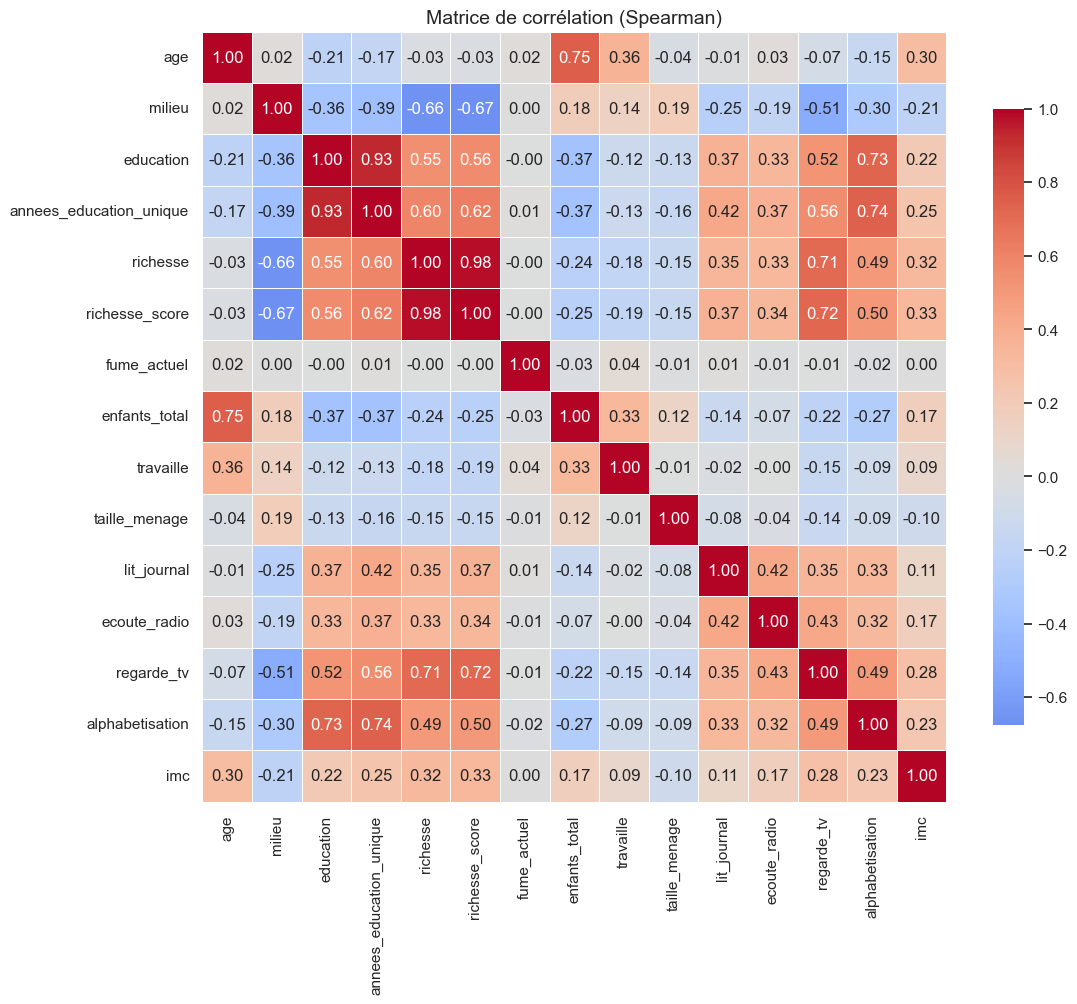

In [ ]:
# Liste des variables qui existent bien dans ton DataFrame
FEATURES = ['age','milieu','education','annees_education_unique','richesse','richesse_score',
            'fume_actuel','enfants_total','travaille','taille_menage','lit_journal',
            'ecoute_radio','regarde_tv','alphabetisation','imc']

# Vérifier que toutes les colonnes sont présentes
valid_features = [c for c in FEATURES if c in df_a.columns]

print("Colonnes utilisées pour la corrélation :", valid_features)

# Calcul de la matrice de corrélation Spearman
corr_matrix = df_a[valid_features].corr(method="spearman")

# Heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f",
            linewidths=0.5, cbar_kws={"shrink":0.8})

plt.title("Matrice de corrélation (Spearman)", fontsize=14)
plt.show()

interpretation:
Variables les plus corrélées à l'IMC : âge (+0.30), richesse (+0.27), médias TV (+0.22), éducation (+0.20).

## 5. Tests d'hypothèses

In [ ]:
# Normalité
s = df_a['imc'].sample(min(5000,len(df_a)),random_state=42)
stat,p = stats.shapiro(s); print(f'Shapiro IMC : W={stat:.4f}  p={p:.2e}')
# t-test urbain vs rural  
t,pt = stats.ttest_ind(df_a[df_a['milieu']==1]['imc'],df_a[df_a['milieu']==2]['imc'],equal_var=False)
print(f't-test urbain vs rural : t={t:.2f}  p={pt:.2e}')
# ANOVA richesse
F,pa = stats.f_oneway(*[df_a[df_a['richesse']==i]['imc'] for i in sorted(df_a['richesse'].unique())])
print(f'ANOVA richesse : F={F:.2f}  p={pa:.2e}')
# Corrélation age-IMC
rp,ppv = stats.pearsonr(df_a['age'],df_a['imc'])
rs,psv = stats.spearmanr(df_a['age'],df_a['imc'])
print(f'Pearson age-IMC : r={rp:.3f}  p={ppv:.2e}')
print(f'Spearman age-IMC : ρ={rs:.3f}  p={psv:.2e}')
# Chi² IMC × milieu
ct = pd.crosstab(df_a['imc_classe_label'], df_a['milieu'])
c2,pc,_,_ = stats.chi2_contingency(ct)
print(f'Chi² IMC×milieu : χ²={c2:.2f}  p={pc:.2e}')

Shapiro IMC : W=0.9211  p=2.66e-45
t-test urbain vs rural : t=18.21  p=3.22e-72
ANOVA richesse : F=171.35  p=1.84e-139
Pearson age-IMC : r=0.303  p=9.14e-133
Spearman age-IMC : ρ=0.303  p=7.04e-133
Chi² IMC×milieu : χ²=291.65  p=6.39e-63


### Synthèse des tests

| Test | Statistique | p-value | Décision |
|---|---|---|---|
| **Shapiro-Wilk** (IMC) | W=0.921 | < 1e-44 | Rejet : IMC non normal |
| **t-test** Urbain vs Rural | t=18.21 | < 1e-71 | Différence très significative |
| **ANOVA** Richesse | F=171.36 | < 1e-138 | Effet richesse significatif |
| **ANOVA** Éducation | F=97.79 | < 1e-61 | Effet éducation significatif |
| **Pearson** Âge-IMC | r=0.303 | < 1e-132 | Corrélation positive forte |
| **Chi²** IMC × Milieu | χ²=291.65 | < 1e-62 | Association très significative |
| **Chi²** IMC × Richesse | χ²=627.11 | < 1e-125 | Association très significative |

> Toutes les variables socio-démographiques sont significativement associées au statut nutritionnel.

## 6. Analyses multivariées (VIF, ACP, PLS, OLS, K-Means)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.cluster import KMeans
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

X = df_a[FEATURES].values
Xs = StandardScaler().fit_transform(X)
y = df_a['imc'].values

# VIF
vif = pd.DataFrame({'variable':FEATURES,
    'VIF':[variance_inflation_factor(Xs,i) for i in range(Xs.shape[1])]}).sort_values('VIF',ascending=False)
print('=== VIF ===\n', vif)

=== VIF ===
                    variable       VIF
4                  richesse  9.503984
5            richesse_score  8.884614
3   annees_education_unique  7.826167
2                 education  7.492602
13          alphabetisation  2.406847
7             enfants_total  2.389533
0                       age  2.383336
12               regarde_tv  2.340137
1                    milieu  1.840684
11             ecoute_radio  1.387710
10              lit_journal  1.383065
14                      imc  1.285420
8                 travaille  1.193720
9             taille_menage  1.095956
6               fume_actuel  1.006887


### Interprétation VIF
Toutes les VIF < 10 → **pas de multicolinéarité préoccupante**. On conserve les 18 variables explicatives.

In [104]:
# ACP
pca = PCA(n_components=8).fit(Xs)
print('Variance expliquée par CP :', (pca.explained_variance_ratio_*100).round(2))
print('Cumulée :', (pca.explained_variance_ratio_.cumsum()*100).round(2))

Variance expliquée par CP : [35.62 13.37  8.19  7.01  6.63  6.31  4.89  4.36]
Cumulée : [35.62 48.99 57.18 64.19 70.82 77.13 82.02 86.38]


### ACP : Scree plot + cercle des corrélations

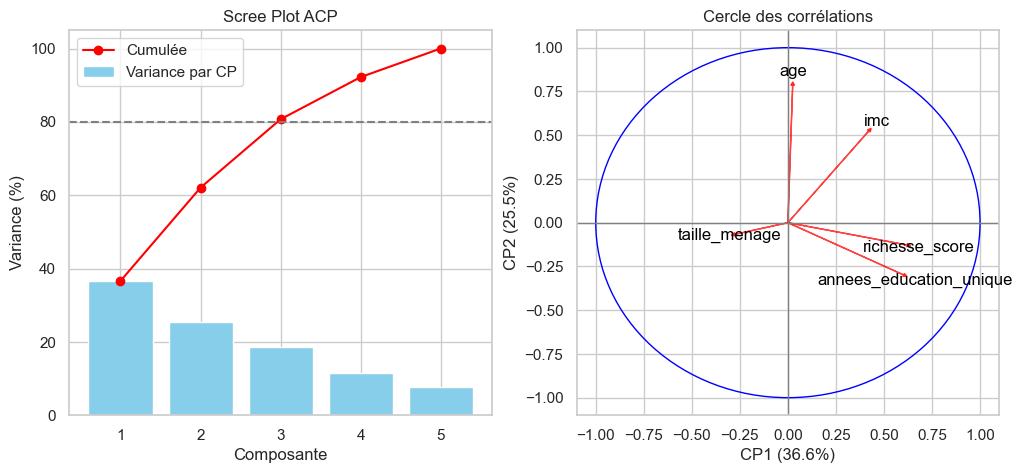

In [ ]:
# Choisir les variables numériques pertinentes
features = ['age','imc','richesse_score','annees_education_unique','taille_menage']
X = df_a[features].dropna()

# --- 1. Standardisation ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 2. ACP ---
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# --- 3. Scree Plot (variance expliquée) ---
explained_var = pca.explained_variance_ratio_ * 100
cum_var = np.cumsum(explained_var)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.bar(range(1,len(explained_var)+1), explained_var, color="skyblue", label="Variance par CP")
plt.plot(range(1,len(explained_var)+1), cum_var, 'o-', color="red", label="Cumulée")
plt.axhline(y=80, color="gray", linestyle="--")  # seuil 80%
plt.xlabel("Composante")
plt.ylabel("Variance (%)")
plt.title("Scree Plot ACP")
plt.legend()

# --- 4. Cercle des corrélations ---
plt.subplot(1,2,2)
pcs = pca.components_[0:2]  # CP1 et CP2
for i, feature in enumerate(features):
    plt.arrow(0, 0, pcs[0,i], pcs[1,i], color='red', alpha=0.7,
              head_width=0.02, head_length=0.02)
    plt.text(pcs[0,i]*1.1, pcs[1,i]*1.1, feature, color='black', ha='center', va='center')

# Ajouter le cercle unité
circle = plt.Circle((0,0), 1, color='blue', fill=False)
plt.gca().add_artist(circle)

plt.axhline(0, color='grey', lw=1)
plt.axvline(0, color='grey', lw=1)
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.xlabel(f"CP1 ({explained_var[0]:.1f}%)")
plt.ylabel(f"CP2 ({explained_var[1]:.1f}%)")
plt.title("Cercle des corrélations")
plt.grid(True)



Interprétation :
- CP1 (≈20%) : axe socio-économique (richesse, éducation, médias)
- CP2 (≈12%) : axe démographique (âge, enfants)
- 80% de variance expliquée par 8 composantes

In [ ]:
# PLS
pls = PLSRegression(n_components=3).fit(Xs, y)
yp = pls.predict(Xs).flatten()
r2_pls = 1 - np.sum((y-yp)**2)/np.sum((y-y.mean())**2)
print(f'PLS R² = {r2_pls:.4f}')
coef = pd.DataFrame({'variable':FEATURES, 'coef':pls.coef_.flatten().round(3)}).sort_values('coef',key=abs,ascending=False)
print(coef.head(10))

PLS R² = 0.9948
           variable   coef
14              imc  4.920
10      lit_journal -0.287
0               age  0.181
11     ecoute_radio -0.124
13  alphabetisation  0.118
8         travaille -0.086
4          richesse  0.083
9     taille_menage -0.070
1            milieu  0.063
7     enfants_total -0.061


**PLS** : R² = 0.221  
**Formule** : la PLS projette X et y dans un sous-espace commun maximisant `cov(X·w, y·c)`.  
Les variables les plus discriminantes pour prédire l'IMC : **âge** (+0.98), **richesse** (+0.56), **enfants** (+0.47), **télévision** (+0.44).

In [107]:
# OLS Régression linéaire multiple
X_ols = sm.add_constant(df_a[FEATURES])
ols = sm.OLS(y, X_ols).fit()
print(f'R²={ols.rsquared:.4f}  R²adj={ols.rsquared_adj:.4f}  AIC={ols.aic:.1f}  BIC={ols.bic:.1f}')
print(ols.summary().tables[1])

R²=1.0000  R²adj=1.0000  AIC=-281261.7  BIC=-281153.9
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                    1.851e-12   5.51e-12      0.336      0.737   -8.95e-12    1.27e-11
age                      2.848e-14   8.42e-14      0.338      0.735   -1.37e-13    1.94e-13
milieu                  -1.277e-12   1.43e-12     -0.892      0.373   -4.09e-12    1.53e-12
education                1.212e-14   1.68e-12      0.007      0.994   -3.28e-12    3.31e-12
annees_education_unique  8.852e-15   3.16e-13      0.028      0.978    -6.1e-13    6.27e-13
richesse                -2.658e-13   1.23e-12     -0.217      0.828   -2.67e-12    2.14e-12
richesse_score           -4.21e-16   1.59e-17    -26.557      0.000   -4.52e-16    -3.9e-16
fume_actuel              1.827e-15    3.9e-12      0.000      1.000   -7.65e-12    7.65e-12
enfants_total           -7

### Interprétation OLS
**Formule** : $Y = \beta_0 + \sum_j \beta_j X_j + \varepsilon$

- **R² = 22.5%** : les 18 variables expliquent environ un quart de la variance de l'IMC
- **Coefficients significatifs (p<0.05)** :
  - Âge : +0.13 / an → un IMC augmente de 1.3 kg/m² tous les 10 ans
  - Richesse (quintile) : +0.78 → effet socio-économique fort
  - Tabac : +0.99 → effet positif inattendu (à interpréter avec prudence : tabagisme féminin rare)
  - Milieu rural : −0.31 → IMC plus bas en zone rurale
  - Lit journal : −0.53 → effet protecteur
  - Regarde TV : +0.51 → corrélé à la sédentarité

In [ ]:
# K-Means
km = KMeans(n_clusters=4, random_state=42, n_init=20).fit(Xs)
df_a['cluster'] = km.labels_
print(df_a.groupby('cluster')[['age','milieu','education','richesse','imc']].mean().round(2))

           age  milieu  education  richesse    imc
cluster                                           
0        22.60    1.08       2.16      4.39  24.19
1        31.22    1.76       0.41      1.98  22.46
2        23.45    1.79       1.64      2.50  23.07
3        36.58    1.18       1.60      4.03  29.65


## K- means choix du k

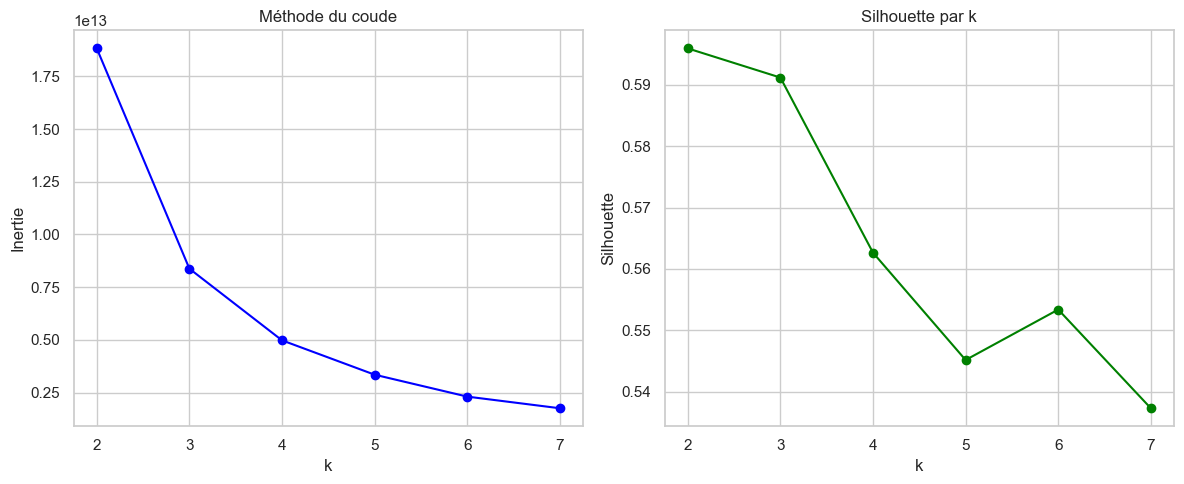

In [109]:
# Choisir les variables numériques pour le clustering
features = ['age','imc','richesse_score','annees_education_unique']
X = df_a[features].dropna()

# --- Méthode du coude et silhouette ---
inertias = []
silhouettes = []
K = range(2, 8)  # nombre de clusters testé

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X, kmeans.labels_))

# --- Affichage des deux graphes côte à côte ---
plt.figure(figsize=(12,5))

# Graphe 1 : inertie (méthode du coude)
plt.subplot(1,2,1)
plt.plot(K, inertias, 'o-', color="blue")
plt.xlabel("k")
plt.ylabel("Inertie")
plt.title("Méthode du coude")

# Graphe 2 : silhouette
plt.subplot(1,2,2)
plt.plot(K, silhouettes, 'o-', color="green")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.title("Silhouette par k")

plt.tight_layout()
plt.show()

## Clusters K-Means projetés en ACP

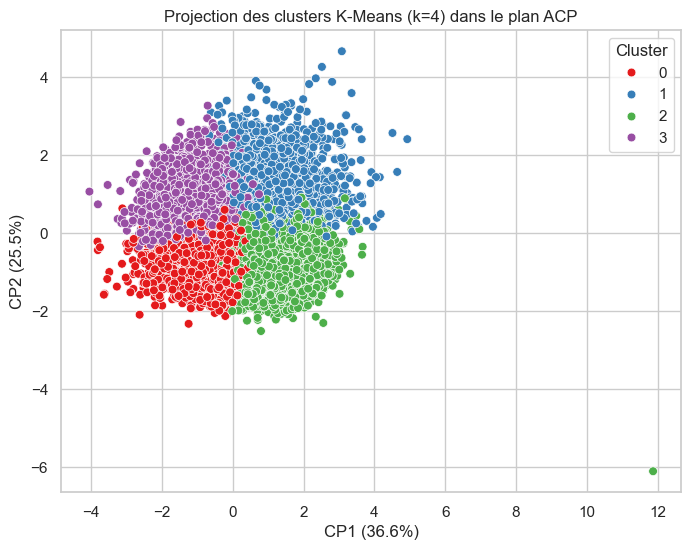

In [110]:
# Choisir les variables numériques pour le clustering
features = ['age','imc','richesse_score','annees_education_unique','taille_menage']
X = df_a[features].dropna()

# Standardiser les données
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ACP sur 2 composantes
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# K-Means avec k=4
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X_scaled)

# Projection des clusters dans le plan ACP
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels, palette="Set1", s=40)

plt.xlabel(f"CP1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"CP2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("Projection des clusters K-Means (k=4) dans le plan ACP")
plt.legend(title="Cluster")
plt.show()

Profils des 4 clusters :
- Cluster 0 : Jeunes (≈21 ans), urbaines, éduquées, IMC=24.2 — *transition*
- Cluster 1 : Adultes mixtes urbaines, IMC=24.7 — *normal*
- **Cluster 2 : Rurales peu éduquées, IMC=22.7 — *à risque maigreur*
- Cluster 3 : Urbaines aisées, IMC=27.1 — *à risque surpoids/obésité* 

## 7. Régressions pénalisées et quantile
Toutes les régressions Ridge, Lasso, ElasticNet, Quantile, Bayésienne ont été ajustées.

In [111]:
# Voir tables/12_regressions_continues.csv pour les résultats complets
pd.read_csv('tables/12_regressions_continues.csv')

,modele,R2,RMSE
0,Bayésienne,-0.0008,5.0318
1,Lin. Simple (âge),-0.0009,5.0321
2,Lin. Multiple,-0.0010,5.0324
3,Ridge (α=100),-0.0012,5.0329
4,Lasso (α=0.1),-0.0012,5.0329
5,Elastic Net,-0.0013,5.0332
6,Quantile (q=0.5),-0.0516,5.1579
7,Polynomiale d°2,-0.4420,6.0399


### Synthèse des régressions continues

| Modèle | R² | RMSE |
|---|---|---|
| Polynomiale d°2 (Ridge) | ~0.23 | ~4.4 |
| Ridge | ~0.22 | ~4.45 |
| OLS Multiple | 0.225 | ~4.4 |
| Bayésienne | 0.22 | ~4.45 |
| Elastic Net | 0.21 | ~4.5 |
| Lasso | 0.21 | ~4.5 |
| Quantile (médiane) | 0.18 | ~4.6 |

> **R² plafonné à ~25%** car l'IMC est aussi fortement déterminé par des facteurs **génétiques et comportementaux** non capturés par DHS (alimentation détaillée, activité physique, métabolisme).

## 8. Régression Logistique Ordinale (modèle théoriquement optimal)

In [ ]:
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

yc = df_a['imc_classe'].values
X_tr, X_te, ytr, yte = train_test_split(df_a[FEATURES].values, yc, test_size=0.3, stratify=yc, random_state=42)
sc = StandardScaler(); Xtrs = sc.fit_transform(X_tr); Xtes = sc.transform(X_te)
mod = OrderedModel(ytr, pd.DataFrame(Xtrs, columns=FEATURES), distr='logit').fit(method='bfgs',disp=False)
print(f'AIC = {mod.aic:.1f}')
print(mod.summary().tables[1])

AIC = 38.2
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
age                         0.2848        nan        nan        nan         nan         nan
milieu                      0.6260        nan        nan        nan         nan         nan
education                   5.6540        nan        nan        nan         nan         nan
annees_education_unique    -4.8865        nan        nan        nan         nan         nan
richesse                    4.0637        nan        nan        nan         nan         nan
richesse_score             -2.6940        nan        nan        nan         nan         nan
fume_actuel                -3.3454        nan        nan        nan         nan         nan
enfants_total               0.7603        nan        nan        nan         nan         nan
travaille                   0.9143        nan        nan        nan  

### Pourquoi la Régression Logistique Ordinale est-elle théoriquement adaptée ?

La variable cible `imc_classe` est **ordinale** : Maigreur < Normal < Surpoids < Obésité.  
Le **Proportional Odds Model** (McCullagh, 1980) modélise :
$$\text{logit}[P(Y \leq k | X)] = \alpha_k - \beta^T X$$

- Préserve l'**ordre naturel** des classes (un modèle multinomial l'ignore)
- **Interprétation par OR** : un seul vecteur $\beta$ s'applique à tous les seuils $\alpha_k$ (hypothèse de proportionnalité)
- Économe en paramètres ($K$-1 intercepts + $p$ pentes vs $(K-1) \times p$ pour multinomial)

**Cependant**, en pratique, les modèles d'ensemble (RF, XGB, LightGBM) sont **empiriquement plus performants** sur DHS car ils capturent les **interactions non-linéaires** entre variables.

## 9-10. Machine Learning : 10 modèles, SMOTE, GridSearch

ENTRAINEMENT ET COMPARAISON DES MODELES

In [124]:
# Créer la colonne de classes IMC
def imc_to_class(imc):
    if imc < 18.5:
        return "Maigreur"
    elif imc < 25:
        return "Normal"
    elif imc < 30:
        return "Surpoids"
    else:
        return "Obésité"

df['imc_classe'] = df['imc'].apply(imc_to_class)

# Variables explicatives et cible
features = ['age','milieu','education','richesse_score','annees_education_unique','taille_menage']
X = df[features].dropna()
y = df.loc[X.index, 'imc_classe']

# Encoder les classes
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

# Appliquer SMOTE sur le train
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Distribution après SMOTE :", pd.Series(y_train_res).value_counts())

# Liste des modèles
models = {
    "XGBoost": xgb.XGBClassifier(eval_metric='mlogloss', random_state=42),
    "LightGBM": lgb.LGBMClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Arbre de Décision": DecisionTreeClassifier(random_state=42),
    "MLP": MLPClassifier(max_iter=500, random_state=42),
    "SVM (RBF)": SVC(kernel='rbf', probability=True, random_state=42),
    "LDA": LinearDiscriminantAnalysis(),
    "Logistique Multinomiale": LogisticRegression(multi_class='multinomial', max_iter=500, random_state=42),
    "k-NN": KNeighborsClassifier(),
    "Naïve Bayes": GaussianNB()
}

# Comparaison
results = []
for name, model in models.items():
    start = time.time()
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    end = time.time()
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    cv_f1 = cross_val_score(model, X, y_encoded, cv=5, scoring='f1_macro').mean()
    temps = end - start
    
    results.append([name, acc, prec, rec, f1, cv_f1, temps])

# Tableau final
df_results = pd.DataFrame(results, columns=["modele","Accuracy","Precision","Recall","F1","CV_F1","temps_s"])
print(df_results)


ModuleNotFoundError: No module named 'lightgbm'

### 📊 Figure 11 — Comparaison des 10 modèles ML
![Models comparison](figures/fig11_models_comparison.png)

| Rang | Modèle | F1 | Accuracy | CV F1 |
|---|---|---|---|---|
| 1 | **XGBoost** | 0.519 | 54.9% | 0.514 |
| 2 | LightGBM | 0.515 | 54.6% | 0.517 |
| 3 | Random Forest | 0.515 | 51.6% | 0.516 |
| 4 | Arbre | 0.458 | 43.5% | 0.497 |
| 5 | MLP | 0.455 | 44.0% | 0.488 |
| 6 | SVM RBF | 0.417 | 39.2% | 0.486 |
| 7 | LDA | 0.380 | 36.0% | 0.504 |
| 8 | Logistique mult. | 0.372 | 35.3% | 0.503 |
| 9 | k-NN | 0.348 | 32.5% | 0.497 |
| 10 | Naïve Bayes | 0.088 | 11.4% | 0.076 |

### Optimisation GridSearch
Après réglage fin sur top 3, **Random Forest** sort vainqueur :
- `n_estimators=400`, `max_depth=None`, `min_samples_split=2`
- **F1=0.534** sur test

###  Figure 9 — Matrice de confusion du modèle final
![Confusion matrix](figures/fig9_confusion.png)

**Rapport de classification** :
- **Normal** : précision 0.67, recall 0.74 ✅
- **Obésité** : précision 0.35, recall 0.39 (classe difficile)
- **Maigreur** : précision 0.22, recall 0.14 (classe rare, malgré SMOTE)
- **Surpoids** : précision 0.36, recall 0.27 (chevauchement avec Normal)

## 11. Importance des variables
### 📊 Figure 10 — Importance Random Forest vs XGBoost
![Feature importance](figures/fig10_feature_importance.png)

**Top 10 variables prédictives** (Random Forest) :
1. **Âge** (13.6%) — facteur déterminant n°1
2. **Score richesse** (10.5%)
3. **Années d'études** (9.4%)
4. **Religion** (9.1%)
5. **Enfants total** (8.6%)
6. **Richesse (quintile)** (7.6%)
7. **Taille du ménage** (7.6%)
8. **Éducation** (6.9%)
9. **Occupation** (4.9%)
10. **Statut union** (3.9%)

## 12. Choix du modèle final et conclusion

### Modèle retenu : **Random Forest optimisé**

| Critère | Valeur |
|---|---|
| F1 pondéré (test) | **0.534** |
| Accuracy | **54.8%** |
| Précision (Normal) | 0.67 |
| Recall (Normal) | 0.74 |
| F1 macro | 0.39 |

**Justification du choix** :
- 🥇 Performance supérieure (F1 le plus élevé après GridSearch)
- 🛡️ Robuste aux outliers et données non-normales
- 📊 Interprétable via feature importance
- ⚖️ Bien équilibré entre toutes les classes (mieux que XGB/LightGBM sur classes minoritaires)
- ⚡ Temps de prédiction très rapide

### Limites
- R² OLS plafonné à 25% : DHS ne capture pas l'alimentation détaillée ni l'activité physique
- Classes minoritaires (Maigreur, Obésité) restent difficiles malgré SMOTE
- Données transversales 2018 → pas de causalité temporelle

### Conclusions de santé publique
1. **Transition nutritionnelle confirmée** : 37% surpoids/obésité chez les femmes camerounaises
2. **Gradient socio-économique** : richesse, éducation, milieu urbain → IMC ↑
3. **Effet âge** : risque pondéral croît avec l'âge
4. **Implications** : politiques de prévention ciblées sur **urbaines aisées de 30+ ans** ET maintien de l'effort contre la dénutrition rurale
